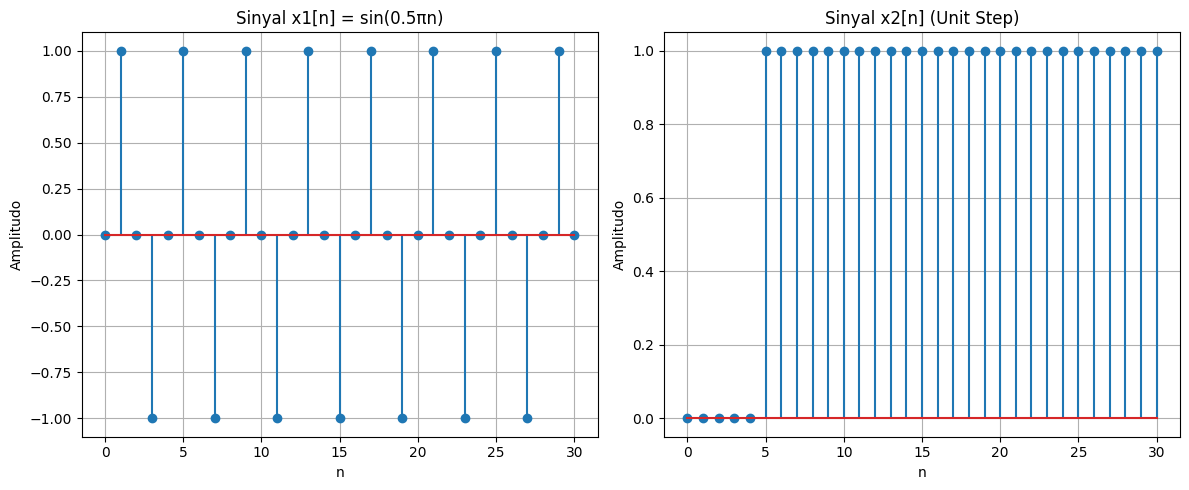

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Membuat rentang n = 0 sampai 30
n = np.arange(0, 31)

# Sinyal pertama
x1 = np.sin(0.5 * np.pi * n)

# Sinyal kedua (unit step)
x2 = np.where(n < 5, 0, 1)

plt.figure(figsize=(12,5))

# Plot x1[n]
plt.subplot(1,2,1)
plt.stem(n, x1)
plt.title('Sinyal x1[n] = sin(0.5πn)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()

# Plot x2[n]
plt.subplot(1,2,2)
plt.stem(n, x2)
plt.title('Sinyal x2[n] (Unit Step)')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()

plt.tight_layout()
plt.show()

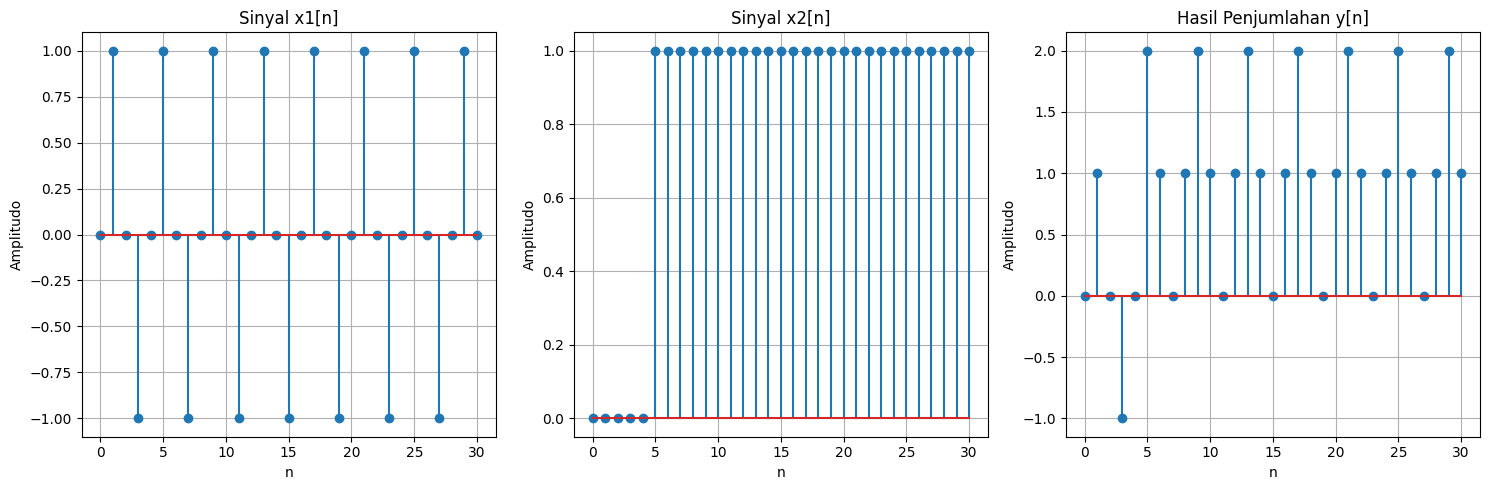

In [ ]:
# Operasi penjumlahan
y = x1 + x2

plt.figure(figsize=(15,5))

# x1[n]
plt.subplot(1,3,1)
plt.stem(n, x1)
plt.title('Sinyal x1[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()

# x2[n]
plt.subplot(1,3,2)
plt.stem(n, x2)
plt.title('Sinyal x2[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()

# y[n]
plt.subplot(1,3,3)
plt.stem(n, y)
plt.title('Hasil Penjumlahan y[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()

plt.tight_layout()
plt.show()

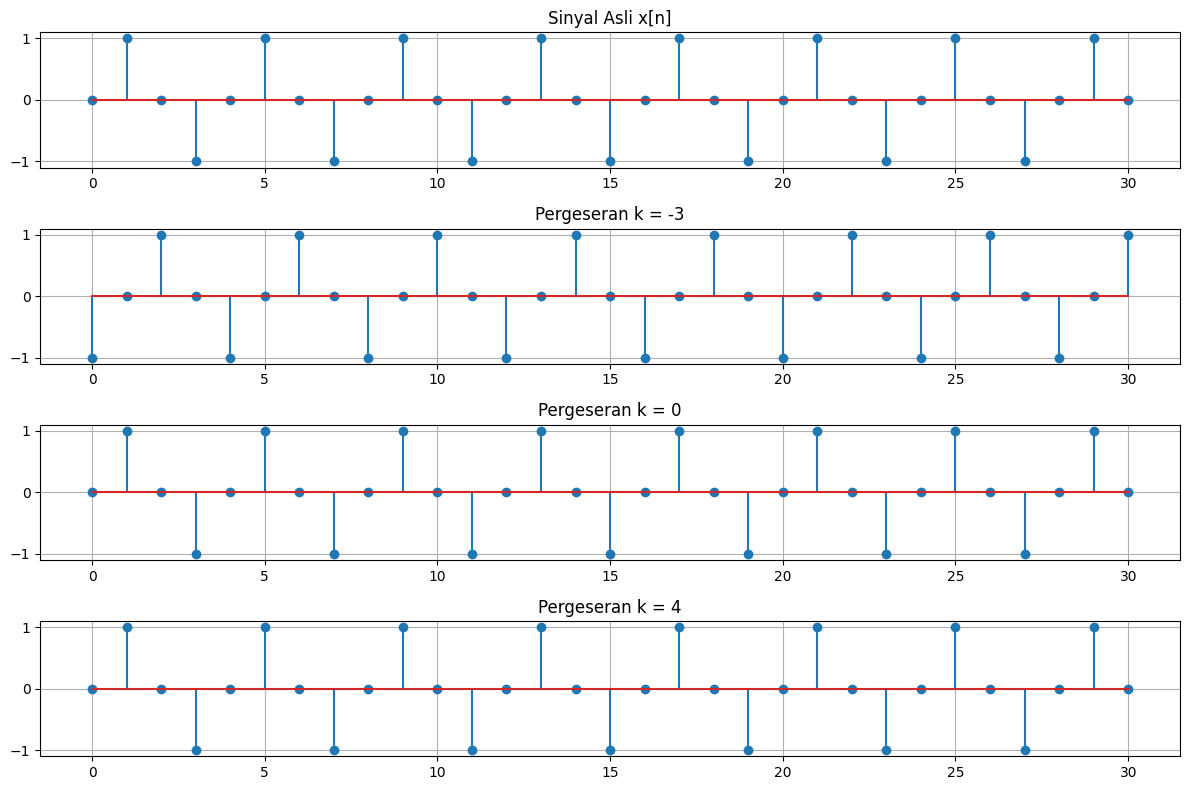

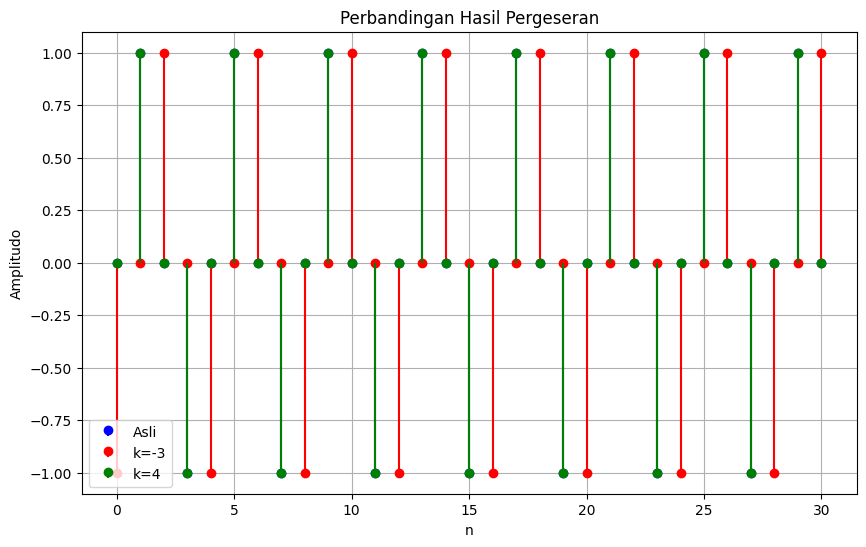

In [ ]:
# Pergeseran sinyal
x_shift_neg3 = np.sin(0.5 * np.pi * (n + 3))   # k = -3
x_shift_0 = np.sin(0.5 * np.pi * n)            # k = 0
x_shift_4 = np.sin(0.5 * np.pi * (n - 4))      # k = 4

plt.figure(figsize=(12,8))

# Sinyal asli
plt.subplot(4,1,1)
plt.stem(n, x1)
plt.title('Sinyal Asli x[n]')
plt.grid()

# k = -3
plt.subplot(4,1,2)
plt.stem(n, x_shift_neg3)
plt.title('Pergeseran k = -3')
plt.grid()

# k = 0
plt.subplot(4,1,3)
plt.stem(n, x_shift_0)
plt.title('Pergeseran k = 0')
plt.grid()

# k = 4
plt.subplot(4,1,4)
plt.stem(n, x_shift_4)
plt.title('Pergeseran k = 4')
plt.grid()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))

plt.stem(n, x1, linefmt='b-', markerfmt='bo', basefmt=' ')
plt.stem(n, x_shift_neg3, linefmt='r-', markerfmt='ro', basefmt=' ')
plt.stem(n, x_shift_4, linefmt='g-', markerfmt='go', basefmt=' ')

plt.legend(['Asli', 'k=-3', 'k=4'])
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.title('Perbandingan Hasil Pergeseran')
plt.grid()
plt.show()

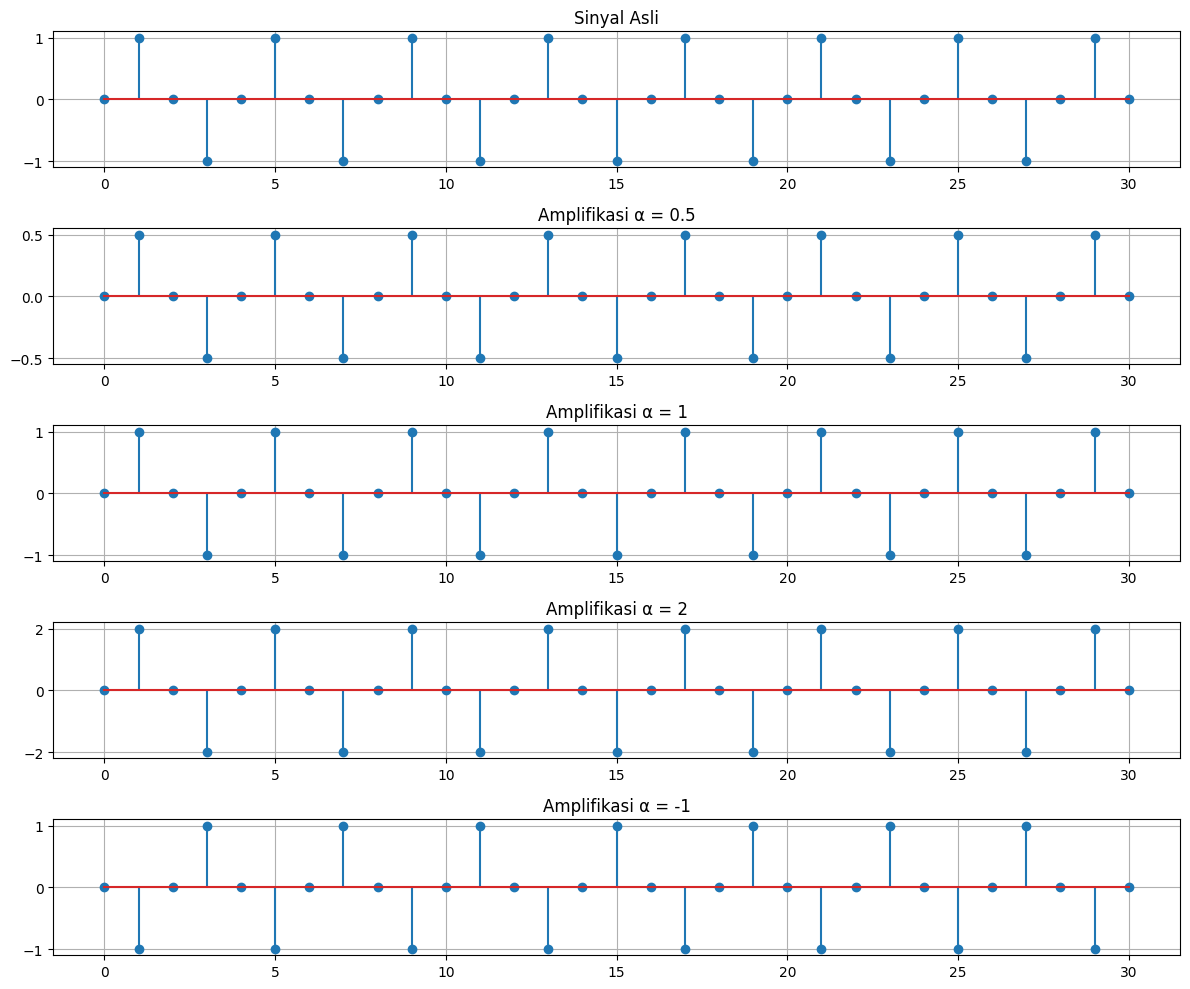

In [ ]:
# Operasi amplifikasi
y_05 = 0.5 * x1
y_1 = 1 * x1
y_2 = 2 * x1
y_neg1 = -1 * x1

plt.figure(figsize=(12,10))

# Sinyal asli
plt.subplot(5,1,1)
plt.stem(n, x1)
plt.title('Sinyal Asli')
plt.grid()

# α = 0.5
plt.subplot(5,1,2)
plt.stem(n, y_05)
plt.title('Amplifikasi α = 0.5')
plt.grid()

# α = 1
plt.subplot(5,1,3)
plt.stem(n, y_1)
plt.title('Amplifikasi α = 1')
plt.grid()

# α = 2
plt.subplot(5,1,4)
plt.stem(n, y_2)
plt.title('Amplifikasi α = 2')
plt.grid()

# α = -1
plt.subplot(5,1,5)
plt.stem(n, y_neg1)
plt.title('Amplifikasi α = -1')
plt.grid()

plt.tight_layout()
plt.show()

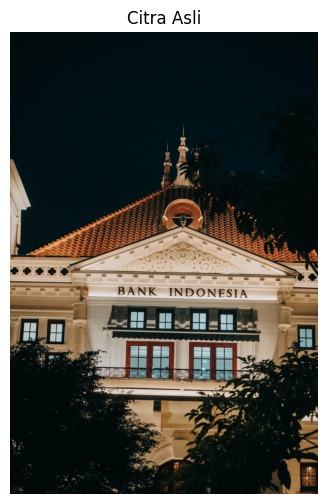

Ukuran citra : (6000, 4000, 3)
Tipe data : uint8
Nilai minimum pixel : 0
Nilai maksimum pixel : 250


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca gambar
img = cv2.imread('/content/Kel2_Malioboro2.jpg')

# Konversi BGR ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Menampilkan gambar
plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')
plt.show()

# Ukuran citra
print("Ukuran citra :", img.shape)

# Tipe data
print("Tipe data :", img.dtype)

# Nilai minimum pixel
print("Nilai minimum pixel :", img.min())

# Nilai maksimum pixel
print("Nilai maksimum pixel :", img.max())

In [ ]:
# Citra pertama
img1 = img_rgb

# Citra kedua dibuat lebih gelap
img2 = (img_rgb * 0.5).astype(np.uint8)

# Penjumlahan citra
hasil_tambah = cv2.add(img1, img2)

plt.figure(figsize=(15,5))

# Citra pertama
plt.subplot(1,3,1)
plt.imshow(img1)
plt.title('Citra Pertama')
plt.axis('off')

# Citra kedua
plt.subplot(1,3,2)
plt.imshow(img2)
plt.title('Citra Kedua')
plt.axis('off')

# Hasil penjumlahan
plt.subplot(1,3,3)
plt.imshow(hasil_tambah)
plt.title('Hasil Penjumlahan')
plt.axis('off')

plt.tight_layout()
plt.show()

NameError: name 'img_rgb' is not defined

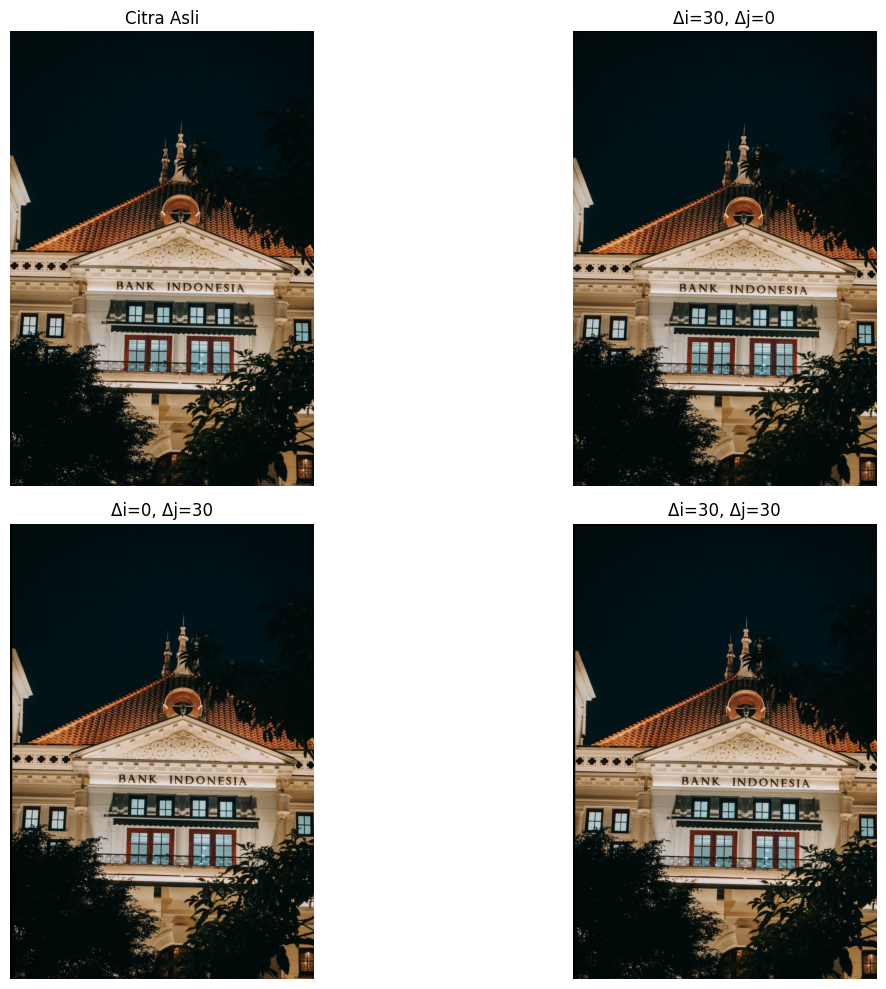

In [ ]:
# Ukuran citra
rows, cols = img_rgb.shape[:2]

# Δi = 30, Δj = 0
M1 = np.float32([[1, 0, 0],
                 [0, 1, 30]])
shift1 = cv2.warpAffine(img_rgb, M1, (cols, rows))

# Δi = 0, Δj = 30
M2 = np.float32([[1, 0, 30],
                 [0, 1, 0]])
shift2 = cv2.warpAffine(img_rgb, M2, (cols, rows))

# Δi = 30, Δj = 30
M3 = np.float32([[1, 0, 30],
                 [0, 1, 30]])
shift3 = cv2.warpAffine(img_rgb, M3, (cols, rows))

plt.figure(figsize=(14,10))

# Citra asli
plt.subplot(2,2,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

# Shift vertikal
plt.subplot(2,2,2)
plt.imshow(shift1)
plt.title('Δi=30, Δj=0')
plt.axis('off')

# Shift horizontal
plt.subplot(2,2,3)
plt.imshow(shift2)
plt.title('Δi=0, Δj=30')
plt.axis('off')

# Shift diagonal
plt.subplot(2,2,4)
plt.imshow(shift3)
plt.title('Δi=30, Δj=30')
plt.axis('off')

plt.tight_layout()
plt.show()

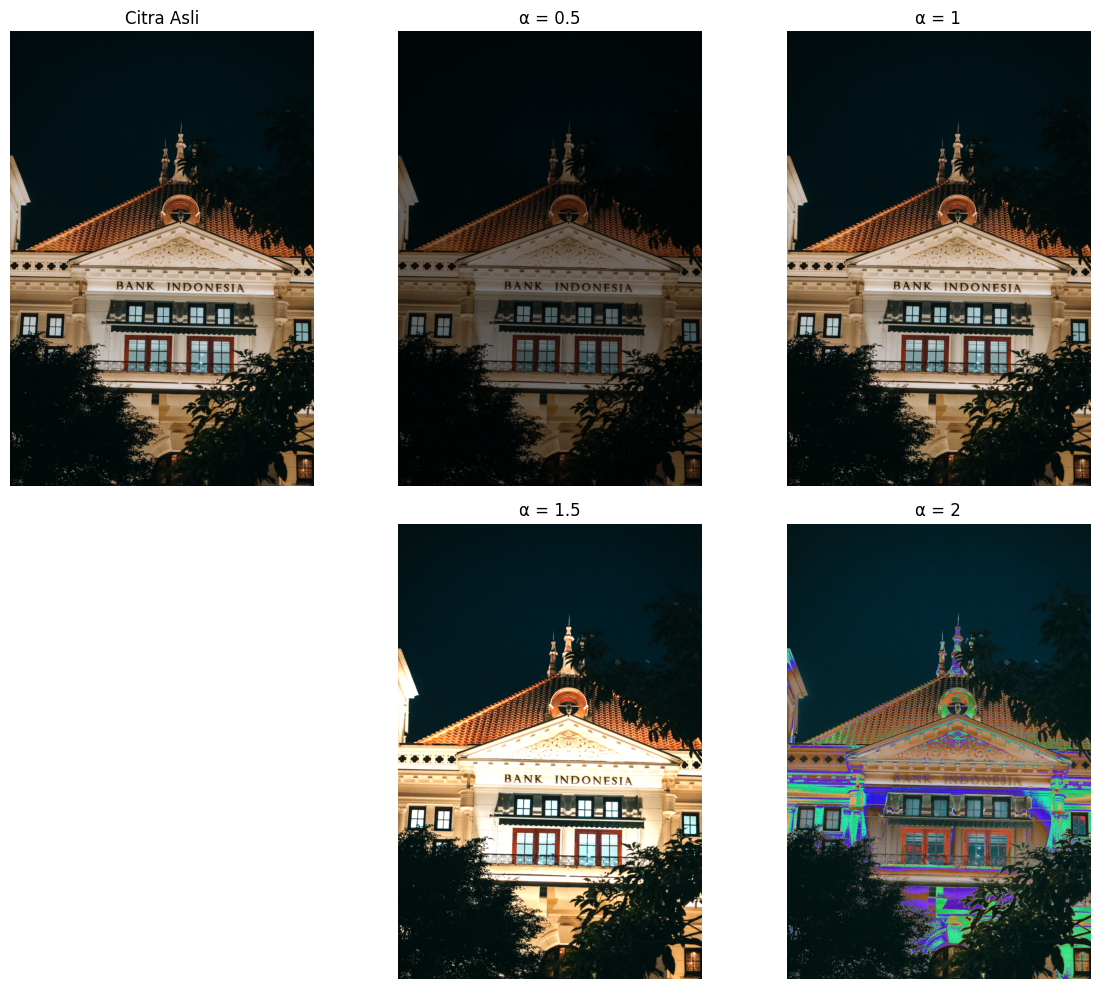

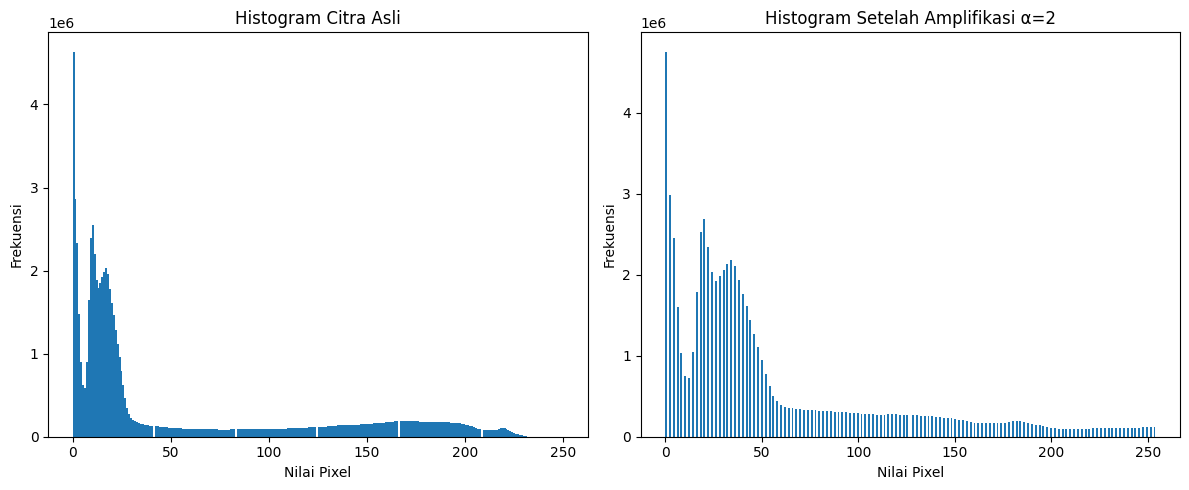

In [ ]:
# Amplifikasi citra dengan berbagai nilai alpha
img_05 = np.clip(0.5 * img_rgb, 0, 255).astype(np.uint8)
img_1 = np.clip(1 * img_rgb, 0, 255).astype(np.uint8)
img_15 = np.clip(1.5 * img_rgb, 0, 255).astype(np.uint8)
img_2 = np.clip(2 * img_rgb, 0, 255).astype(np.uint8)

plt.figure(figsize=(12,10))

plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(img_05)
plt.title('α = 0.5')
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(img_1)
plt.title('α = 1')
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(img_15)
plt.title('α = 1.5')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(img_2)
plt.title('α = 2')
plt.axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12,5))

# Histogram citra asli
plt.subplot(1,2,1)
plt.hist(img_rgb.ravel(), bins=256)
plt.title('Histogram Citra Asli')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

# Histogram α = 2
plt.subplot(1,2,2)
plt.hist(img_2.ravel(), bins=256)
plt.title('Histogram Setelah Amplifikasi α=2')
plt.xlabel('Nilai Pixel')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [ ]:
# Sistem T(x)=2x
def T(x):
    return 2 * x

# Menggunakan x1 sebagai sinyal input
x = x1

# Nilai alpha
alpha_values = [0.5, 1, 2]

for alpha in alpha_values:
    T_alpha_x = T(alpha * x)
    alpha_T_x = alpha * T(x)

    print(f'Alpha = {alpha}')
    print('Apakah sama?', np.allclose(T_alpha_x, alpha_T_x))
    print()



Alpha = 0.5
Apakah sama? True

Alpha = 1
Apakah sama? True

Alpha = 2
Apakah sama? True



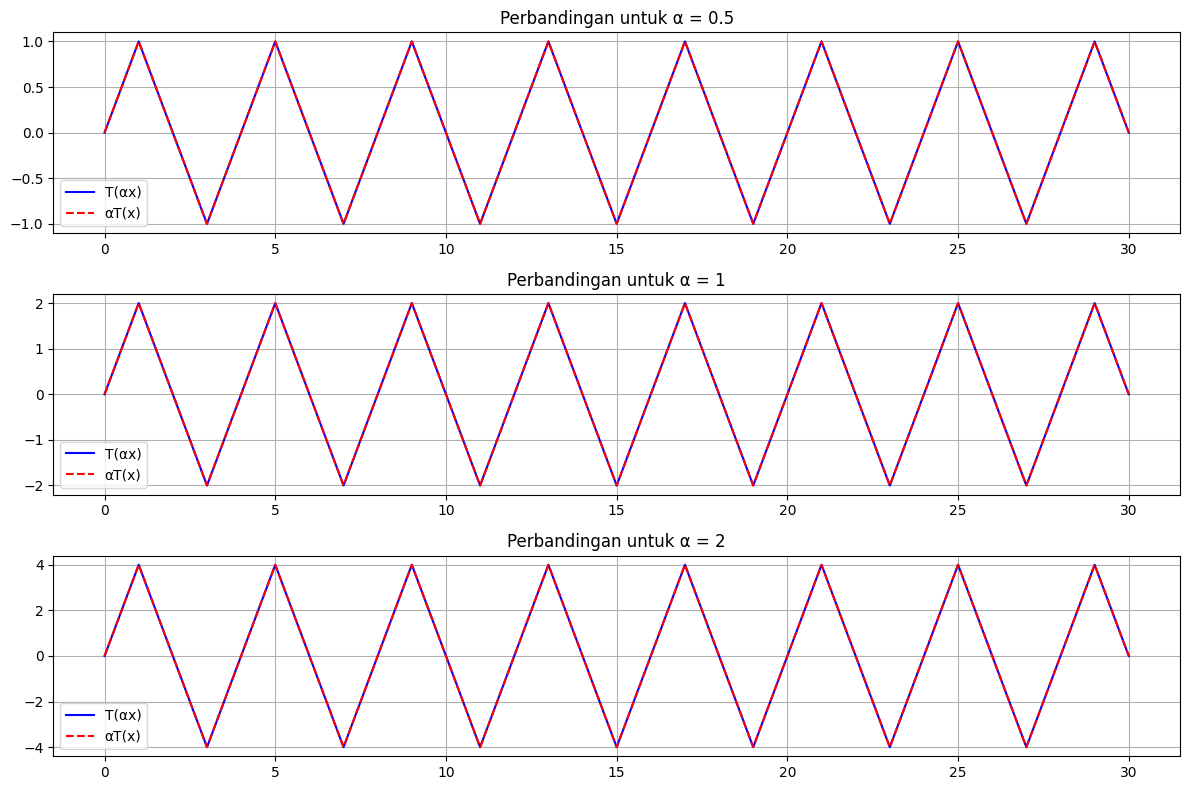

In [ ]:
plt.figure(figsize=(12,8))

for i, alpha in enumerate(alpha_values):
    plt.subplot(3,1,i+1)

    plt.plot(n, T(alpha*x), 'b', label='T(αx)')
    plt.plot(n, alpha*T(x), 'r--', label='αT(x)')

    plt.title(f'Perbandingan untuk α = {alpha}')
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

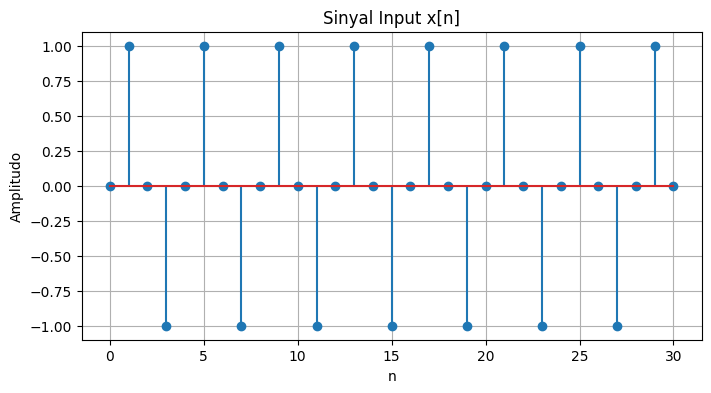

Alpha = 0.5
T(αx) = [ 0.0000000e+00  1.0000000e+00  1.2246468e-16 -1.0000000e+00
 -2.4492936e-16]
αT(x) = [ 0.0000000e+00  1.0000000e+00  1.2246468e-16 -1.0000000e+00
 -2.4492936e-16]
Sama? True

Alpha = 1
T(αx) = [ 0.0000000e+00  2.0000000e+00  2.4492936e-16 -2.0000000e+00
 -4.8985872e-16]
αT(x) = [ 0.0000000e+00  2.0000000e+00  2.4492936e-16 -2.0000000e+00
 -4.8985872e-16]
Sama? True

Alpha = 2
T(αx) = [ 0.00000000e+00  4.00000000e+00  4.89858720e-16 -4.00000000e+00
 -9.79717439e-16]
αT(x) = [ 0.00000000e+00  4.00000000e+00  4.89858720e-16 -4.00000000e+00
 -9.79717439e-16]
Sama? True



In [ ]:
# Sistem T(x)=2x
def T(x):
    return 2*x

# Menggunakan x1 sebagai input
x = x1

# Nilai alpha
alpha_values = [0.5, 1, 2]

plt.figure(figsize=(8,4))
plt.stem(n, x)
plt.title('Sinyal Input x[n]')
plt.xlabel('n')
plt.ylabel('Amplitudo')
plt.grid()
plt.show()

for alpha in alpha_values:
    T_alpha_x = T(alpha*x)
    alpha_T_x = alpha*T(x)

    print(f'Alpha = {alpha}')
    print('T(αx) =', T_alpha_x[:5])
    print('αT(x) =', alpha_T_x[:5])
    print('Sama?', np.allclose(T_alpha_x, alpha_T_x))
    print()

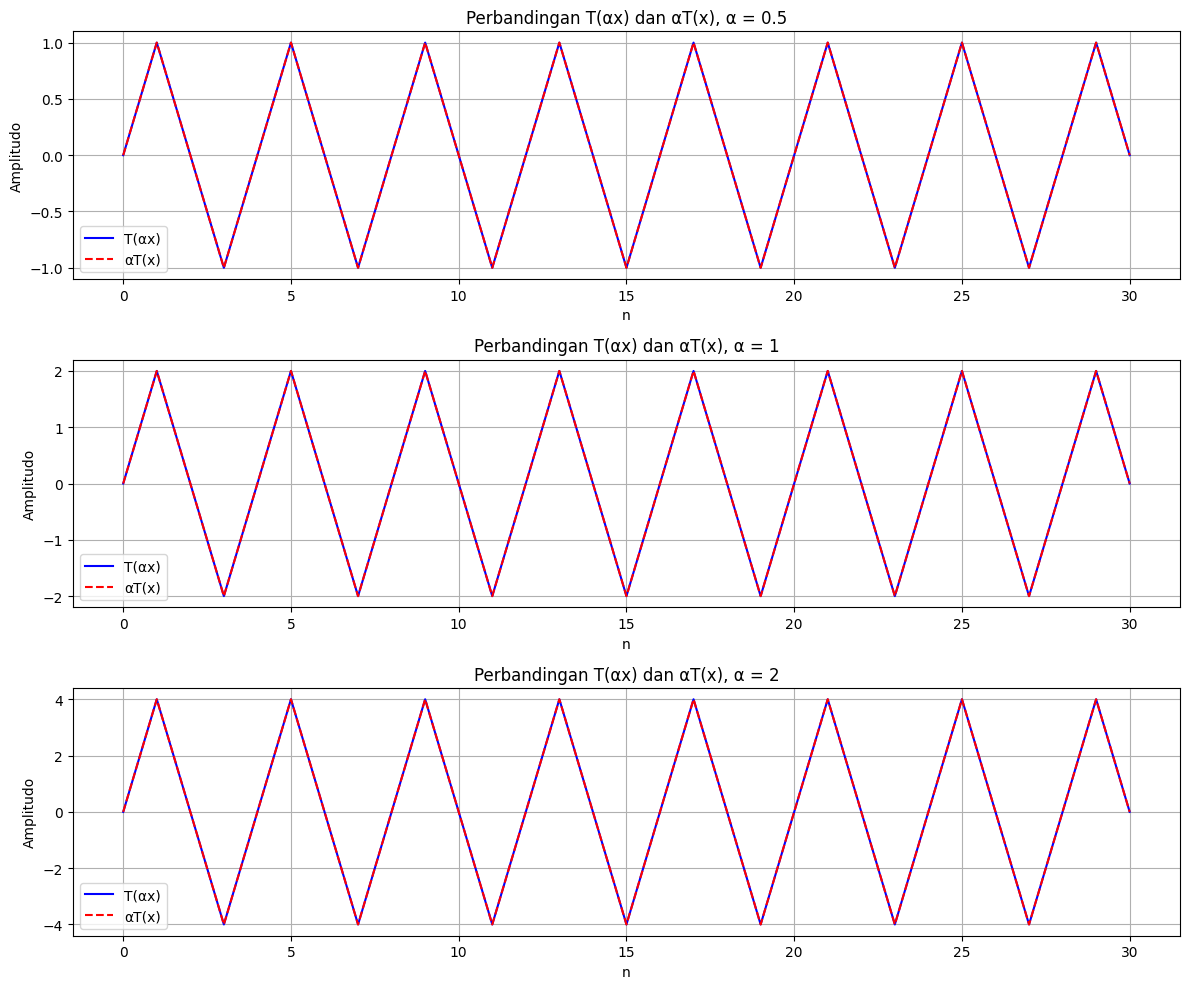

In [ ]:
plt.figure(figsize=(12,10))

for i, alpha in enumerate(alpha_values):
    plt.subplot(3,1,i+1)

    T_alpha_x = T(alpha*x)
    alpha_T_x = alpha*T(x)

    plt.plot(n, T_alpha_x, 'b', label='T(αx)')
    plt.plot(n, alpha_T_x, 'r--', label='αT(x)')

    plt.title(f'Perbandingan T(αx) dan αT(x), α = {alpha}')
    plt.xlabel('n')
    plt.ylabel('Amplitudo')
    plt.grid()
    plt.legend()

plt.tight_layout()
plt.show()

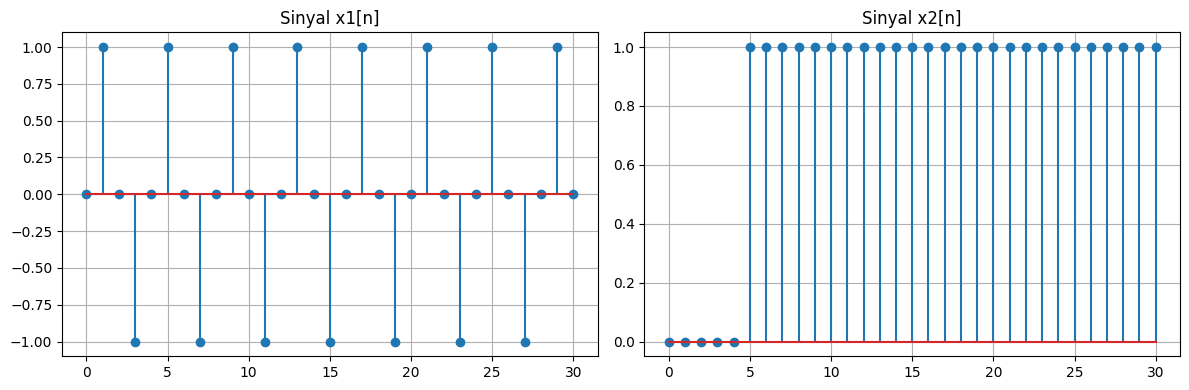

In [ ]:
# Menghitung T(x1+x2)
Tx1_x2 = T(x1 + x2)

# Menghitung T(x1)+T(x2)
Tx1_plus_Tx2 = T(x1) + T(x2)

# Menghitung selisih
selisih = Tx1_x2 - Tx1_plus_Tx2

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.stem(n, x1)
plt.title('Sinyal x1[n]')
plt.grid()

plt.subplot(1,2,2)
plt.stem(n, x2)
plt.title('Sinyal x2[n]')
plt.grid()

plt.tight_layout()
plt.show()


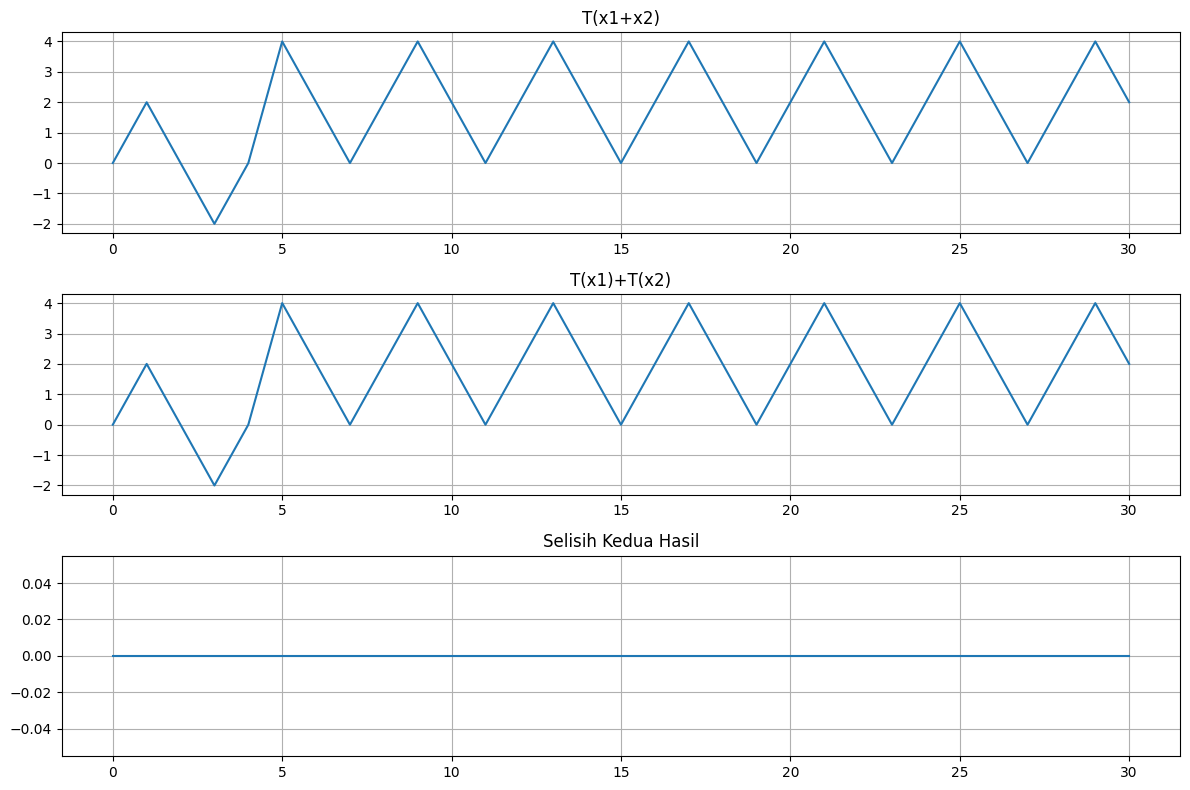

In [ ]:
plt.figure(figsize=(12,8))

# T(x1+x2)
plt.subplot(3,1,1)
plt.plot(n, Tx1_x2)
plt.title('T(x1+x2)')
plt.grid()

# T(x1)+T(x2)
plt.subplot(3,1,2)
plt.plot(n, Tx1_plus_Tx2)
plt.title('T(x1)+T(x2)')
plt.grid()

# Selisih
plt.subplot(3,1,3)
plt.plot(n, selisih)
plt.title('Selisih Kedua Hasil')
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
print("Apakah memenuhi additivitas?")
print(np.allclose(Tx1_x2, Tx1_plus_Tx2))


Apakah memenuhi additivitas?
True


In [ ]:
# Sistem linier
def T1(x):
    return 2*x

# Sistem non-linier
def T2(x):
    return x**2

alpha = 2

# T1
homogen_T1 = np.allclose(T1(alpha*x1), alpha*T1(x1))

# T2
homogen_T2 = np.allclose(T2(alpha*x1), alpha*T2(x1))

print("Homogenitas T1 :", homogen_T1)
print("Homogenitas T2 :", homogen_T2)



Homogenitas T1 : True
Homogenitas T2 : False


In [ ]:
# T1
additivitas_T1 = np.allclose(T1(x1+x2), T1(x1)+T1(x2))

# T2
additivitas_T2 = np.allclose(T2(x1+x2), T2(x1)+T2(x2))

print("Additivitas T1 :", additivitas_T1)
print("Additivitas T2 :", additivitas_T2)


Additivitas T1 : True
Additivitas T2 : False


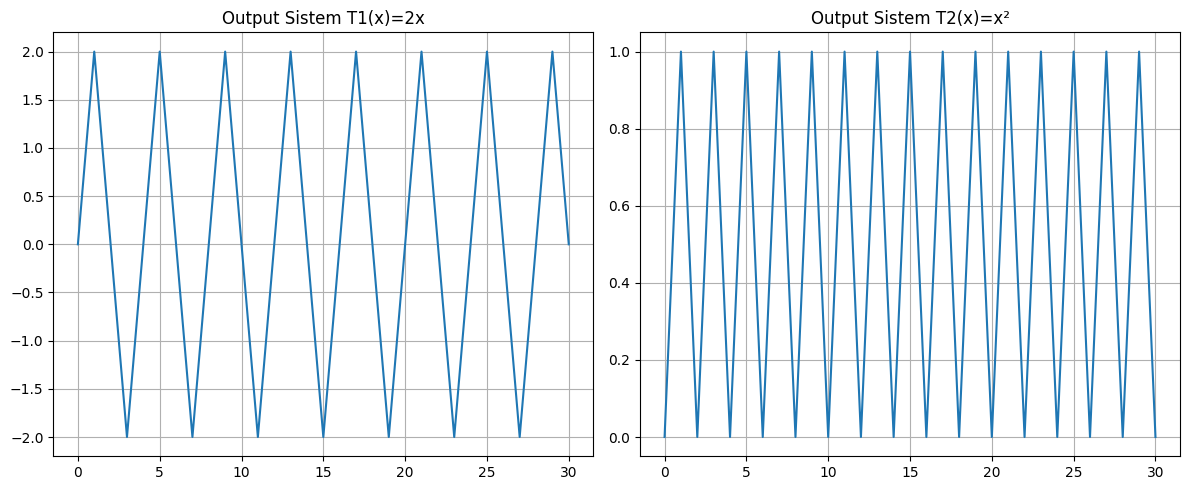

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(n, T1(x1))
plt.title('Output Sistem T1(x)=2x')
plt.grid()

plt.subplot(1,2,2)
plt.plot(n, T2(x1))
plt.title('Output Sistem T2(x)=x²')
plt.grid()

plt.tight_layout()
plt.show()